# U03 · NumPy 练习

做完 `lesson.ipynb` 再做这个。
**4 道题，最后一道是完整的线性回归训练**。

## 练习 3.1 · 广播判断

**不运行代码**，先判断下面 6 组形状能不能广播，能的话结果形状是？

| # | 形状 A | 形状 B | 合法? | 结果 shape |
|---|--------|--------|-------|-----------|
| 1 | (3,4)    | (4,)    | ? | ? |
| 2 | (3,4)    | (3,)    | ? | ? |
| 3 | (3,4)    | (3,1)   | ? | ? |
| 4 | (8,1,6)  | (7,1)   | ? | ? |
| 5 | (2,3,4)  | (4,)    | ? | ? |
| 6 | (2,3,4)  | (2,4)   | ? | ? |

在 markdown 或下一个 cell 里写答案，然后跑代码验证。

In [ ]:
import numpy as np

# 验证时取消对应注释
# print('1:', (np.ones((3,4))    + np.ones((4,))    ).shape)
# print('2:', (np.ones((3,4))    + np.ones((3,))    ).shape)
# print('3:', (np.ones((3,4))    + np.ones((3,1))   ).shape)
# print('4:', (np.ones((8,1,6))  + np.ones((7,1))   ).shape)
# print('5:', (np.ones((2,3,4))  + np.ones((4,))    ).shape)
# print('6:', (np.ones((2,3,4))  + np.ones((2,4))   ).shape)

ValueError: operands could not be broadcast together with shapes (2,3,4) (2,4) 

## 练习 3.2 · 把循环改成向量化

下面 3 段代码都用了循环，请用**一行 NumPy 操作**改写。

In [12]:
import numpy as np

a = np.random.randn(1000)

# ===== 题 1: 计算所有元素的平方和 =====
# 循环版
s_loop = 0.0
for x in a:
    s_loop += x ** 2

# TODO: 向量化版
# s_vec = (a ** 2).sum()  # 提示：** 和 .sum()
s_vec = np.sum(a ** 2)  # 提示：** 和 .sum()


print('题 1 一致?', np.isclose(s_loop, s_vec) if s_vec is not None else 'TODO')

题 1 一致? True


In [50]:
# ===== 题 2: 把所有负数替换成 0（ReLU！）=====
import numpy as np
a = np.array([-1.0, 2.0, -3.5, 4.0, -0.5])

# 循环版
b_loop = a.copy()
for i in range(len(b_loop)):
    if b_loop[i] < 0:
        b_loop[i] = 0

# TODO: 向量化版（两种写法都试）
b_vec1 = np.maximum(a, 0)   # 提示：np.maximum
b_vec2 = a.copy()
b_vec2[b_vec2 < 0] = 0   # 提示：布尔索引 先 copy，再 b[b<0] = 0

print('循环版:', b_loop)
print('向量化1:', b_vec1)
print('向量化2:', b_vec2)

循环版: [0. 2. 0. 4. 0.]
向量化1: [0. 2. 0. 4. 0.]
向量化2: [0. 2. 0. 4. 0.]


In [16]:
# ===== 题 3: 给矩阵每一行减去该行的平均值（行归一化）=====
import numpy as np
X = np.array([[1.0, 2.0, 3.0],
              [10.0, 20.0, 30.0],
              [100.0, 200.0, 300.0]])

# 循环版
Y_loop = X.copy()
for i in range(X.shape[0]):
    mean = X[i].mean()
    Y_loop[i] = X[i] - mean

# TODO: 向量化版
# 提示：X.mean(axis=1) 得到每行的均值，shape (3,)
# 但 X 是 (3,3)，广播减 (3,) 会失败（见 lesson §3）
# 需要把均值变成 (3,1)
Y_vec = X - X.mean(axis=1, keepdims=True)

print('循环:\n', Y_loop)
print('向量化:\n', Y_vec)

循环:
 [[  -1.    0.    1.]
 [ -10.    0.   10.]
 [-100.    0.  100.]]
向量化:
 [[  -1.    0.    1.]
 [ -10.    0.   10.]
 [-100.    0.  100.]]


## 练习 3.3 · batch 前向

实现一个 2 层的前向传播，**必须一次处理整个 batch**（不准写循环）。

结构：
```
输入 x: (batch=32, in=10)
  ↓ 经过 Linear 1: W1 (10, 20), b1 (20,)
  ↓ ReLU
  ↓ 经过 Linear 2: W2 (20, 3),  b2 (3,)
输出 y: (batch=32, out=3)
```

In [17]:
import numpy as np
np.random.seed(42)

x = np.random.randn(32, 10)
W1 = np.random.randn(10, 20) * 0.1
b1 = np.zeros(20)
W2 = np.random.randn(20, 3) * 0.1
b2 = np.zeros(3)

def forward(x, W1, b1, W2, b2):
    # TODO: 实现
    z1 = x @ W1 + b1
    a1 = np.maximum(0, z1)
    z2 = a1 @ W2 + b2
    return z2
    # 提示：
    # z1 = x @ W1 + b1          ← 形状?
    # a1 = relu(z1)              ← 用 np.maximum(0, z1)
    # z2 = a1 @ W2 + b2
    # return z2
    pass

y = forward(x, W1, b1, W2, b2)
print('输出 shape:', y.shape)
assert y.shape == (32, 3), f'形状错了: {y.shape}'
print('✅ 通过')

输出 shape: (32, 3)
✅ 通过


## 练习 3.4 🌟 · 线性回归完整训练（本单元过关标准）

**目标**：拟合真实关系 $y = 2x + 3$，用 NumPy 手写完整训练循环。

### 任务流程
1. 生成数据（已给）
2. 初始化参数 w, b
3. 写前向、loss、梯度、更新
4. 循环训练 500 次
5. 训练完 w 应该接近 2，b 接近 3

### 关键公式（先自己推一遍，再写代码）

前向（batch 版）：$\hat{y} = x \cdot w + b$
损失：$L = \frac{1}{N}\sum (\hat{y} - y)^2$

梯度（你来推 —— 这是 U2 的应用）：
- $\partial L / \partial w = ?$
- $\partial L / \partial b = ?$

<details>
<summary>推导卡住再展开</summary>

对 w 求偏导（链式法则，外层 $u^2 \to 2u$，内层对 w 导数是 $x_i$）：
$$ \frac{\partial L}{\partial w} = \frac{2}{N} \sum x_i (\hat{y}_i - y_i) $$

对 b 求偏导（内层对 b 导数是 1）：
$$ \frac{\partial L}{\partial b} = \frac{2}{N}\sum (\hat{y}_i - y_i) $$

**向量化写法**：
- `dw = 2 * (x * (y_pred - y)).mean()`
- `db = 2 * (y_pred - y).mean()`
</details>

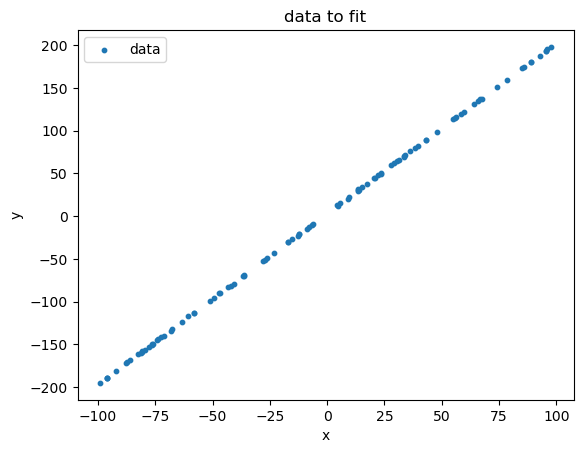

In [42]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# ===== 1. 生成数据：y = 2x + 3 + 噪声 =====
N = 100
x = np.random.uniform(-100, 100, N)             # (100,)
y = 2 * x + 3 + np.random.randn(N) * 0.5    # 真实标签，带噪声

plt.scatter(x, y, s=10, label='data')
plt.xlabel('x'); plt.ylabel('y'); plt.legend()
plt.title('data to fit')
plt.show()

In [69]:
# ===== 2-5. 训练循环 =====
from typing import Any


import numpy as np  # pyright: ignore[reportMissingImports]

# 2. 初始化参数（随便给个值）
w = 0.1
b = 0.2

lr1 = 0.00002       # 学习率
lr2 = 0.009       # 学习率
N = 100
x: Any = np.random.uniform(-100, 100, N)  
y: Any = x * 2 + 3 + np.random.normal(0, 5, N)  # 带噪声
# print(x)
# print(y)
epochs = 500    # 训练轮数

loss_history = []

for epoch in range(epochs):
  
    # TODO (3.4a) 前向：y_pred = ?
    y_pred = x * w + b

    # TODO (3.4b) 损失（均方误差）
    loss = np.mean((y - y_pred) ** 2)

    # TODO (3.4c) 梯度
    dw = 2 * (x * (y_pred - y)).mean() 
    db = np.mean(2 * (y_pred - y))

    # TODO (3.4d) 更新参数
    w = w - lr1 * dw
    b = b - lr2 * db

    loss_history.append(loss)
    if epoch % 10 == 0:
        print(f'epoch {epoch:3d}  loss={loss:.4f}  w={w:.3f}  b={b:.3f}')

print(f'\n最终 w = {w:.3f} (理论 2.0)')
print(f'最终 b = {b:.3f} (理论 3.0)')

epoch   0  loss=13576.1278  w=0.384  b=0.181
epoch  10  loss=572.0646  w=1.683  b=0.372
epoch  20  loss=56.4197  w=1.941  b=0.768
epoch  30  loss=34.4036  w=1.993  b=1.146
epoch  40  loss=32.3768  w=2.003  b=1.471
epoch  50  loss=31.4912  w=2.005  b=1.743
epoch  60  loss=30.8958  w=2.006  b=1.971
epoch  70  loss=30.4823  w=2.006  b=2.161
epoch  80  loss=30.1947  w=2.006  b=2.319
epoch  90  loss=29.9946  w=2.006  b=2.452
epoch 100  loss=29.8554  w=2.006  b=2.562
epoch 110  loss=29.7585  w=2.006  b=2.654
epoch 120  loss=29.6912  w=2.006  b=2.730
epoch 130  loss=29.6443  w=2.007  b=2.794
epoch 140  loss=29.6117  w=2.007  b=2.848
epoch 150  loss=29.5890  w=2.007  b=2.892
epoch 160  loss=29.5732  w=2.007  b=2.929
epoch 170  loss=29.5622  w=2.007  b=2.960
epoch 180  loss=29.5545  w=2.007  b=2.986
epoch 190  loss=29.5492  w=2.007  b=3.008
epoch 200  loss=29.5455  w=2.007  b=3.026
epoch 210  loss=29.5430  w=2.007  b=3.041
epoch 220  loss=29.5412  w=2.007  b=3.053
epoch 230  loss=29.5399  w=2.0

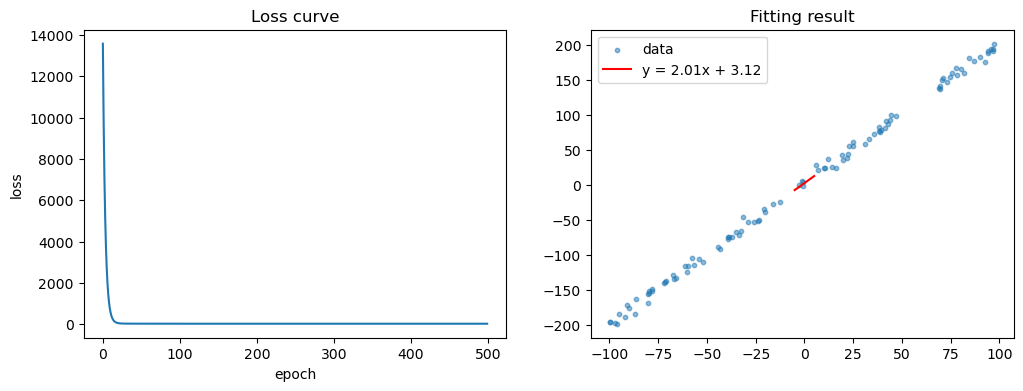

In [71]:
# ===== 可视化结果 =====
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左图：loss 下降曲线
axes[0].plot(loss_history)
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss')
axes[0].set_title('Loss curve')

# 右图：拟合结果
axes[1].scatter(x, y, s=10, alpha=0.5, label='data')
xs = np.linspace(-5, 5, 100)
axes[1].plot(xs, w * xs + b, 'r-', label=f'y = {w:.2f}x + {b:.2f}')
axes[1].legend()
axes[1].set_title('Fitting result')

plt.show()

---
## ✅ 过关标准

- [ ] 3.1 广播判断至少 5/6 题正确
- [ ] 3.2 三段循环都成功向量化
- [ ] 3.3 batch 前向通过 assert
- [ ] 3.4 **w ≈ 2.0, b ≈ 3.0，loss 曲线下降** 🎯

全部跑通告诉我 **「U3 做完了」**，进入 **U4 · PyTorch 基础**。

🔥 U3 最重要的认知：从今以后你看每个张量第一反应是 —— **它的 shape 是什么？**